In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import os

import sys
sys.path.append('..') 

from src.kitti_utils import (parse_timestamps, get_frame_interval, 
                             load_oxts_velocity, load_velodyne_points, 
                             project_velo_to_image, load_kitti_calib)
from src.optical_flow import compute_sparse_flow
from src.geometry import calculate_tti_from_points, estimate_dynamic_foe
from src.visualization import plot_tti_and_depth, plot_lidar_overlay, plot_validation_stats

# Paths to dataset
BASE_PATH = "D:/reyci/Politecnico di Milano/2025-2/Image Analysis and CV/Project/Code/IACV-Depth-Estimation-from-Temporal-Stereo-in-Monocular-Driving-Sequences-/data/raw/2011_09_26_drive_0001_extract"
IMG_PATH = os.path.join(BASE_PATH, "image_02/data")
OXTS_PATH = os.path.join(BASE_PATH, "oxts/data")
TIME_PATH = os.path.join(BASE_PATH, "image_02/timestamps.txt")
CALIB_CAM_PATH = os.path.join(BASE_PATH, "calib/calib_cam_to_cam.txt")
CALIB_VELO_PATH = os.path.join(BASE_PATH, "calib/calib_velo_to_cam.txt")

In [2]:
# Define the frames to compare
idx_t = 5
idx_t1 = 8

# Load images
img_t = cv2.imread(os.path.join(IMG_PATH, f"{idx_t:010d}.png"))
img_t1 = cv2.imread(os.path.join(IMG_PATH, f"{idx_t1:010d}.png"))

# Load metadata
timestamps = parse_timestamps(TIME_PATH)
dt = get_frame_interval(timestamps, idx_t)
vf = load_oxts_velocity(OXTS_PATH, idx_t)

print(f"Delta t: {dt:.4f} s | Forward velocity vf: {vf:.2f} m/s")

Delta t: 0.1031 s | Forward velocity vf: 13.30 m/s


In [3]:
# Load real calibration (required to obtain the theoretical FOE)
P_rect, Tr_velo_to_cam = load_kitti_calib(CALIB_CAM_PATH, CALIB_VELO_PATH)

# Define the FOE (Focus of Expansion)
# the theoretical FOE coincides with the optical center (cx, cy)
# We extract cx and cy from the P_rect matrix (column 2, rows 0 and 1)
foe = np.array([P_rect[0, 2], P_rect[1, 2]])

# Compute sparse optical flow (Lucas-Kanade)
p0, p1 = compute_sparse_flow(img_t, img_t1)

# Filter noise in optical flow
# Compute the motion magnitude of each point
flow_dist = np.linalg.norm(p1 - p0, axis=1)

# Keep only points that moved more than 0.5 pixels
# Static points or sub-pixel noise generate infinite TTIs
mask_flow = flow_dist > 0.05

# Compute TTI (Time-to-Impact) in seconds
# Using only points that passed the motion filter
ttis = calculate_tti_from_points(p0[mask_flow], p1[mask_flow], foe, dt)
p0_valid = p0[mask_flow]

# Estimate depth (Z = vf * tau)
depths_estimated = vf * ttis

# Kinematic Range Filter (Outlier Removal)
# Discard physically impossible depths for this scenario (2m to 80m)
# This removes the large scale errors we observed earlier
valid_z_mask = (depths_estimated > 2) & (depths_estimated < 80)

# Define final variables for LiDAR validation (Cell 5)
final_p0 = p0_valid[valid_z_mask]
final_depths = depths_estimated[valid_z_mask]

# --- Status report ---
print(f"Theoretical FOE (Optical Center): {foe}")
print(f"Initially detected points: {len(p0)}")
print(f"Valid points after flow and depth filtering: {len(final_p0)}")

Theoretical FOE (Optical Center): [609.5593 172.854 ]
Initially detected points: 46
Valid points after flow and depth filtering: 11


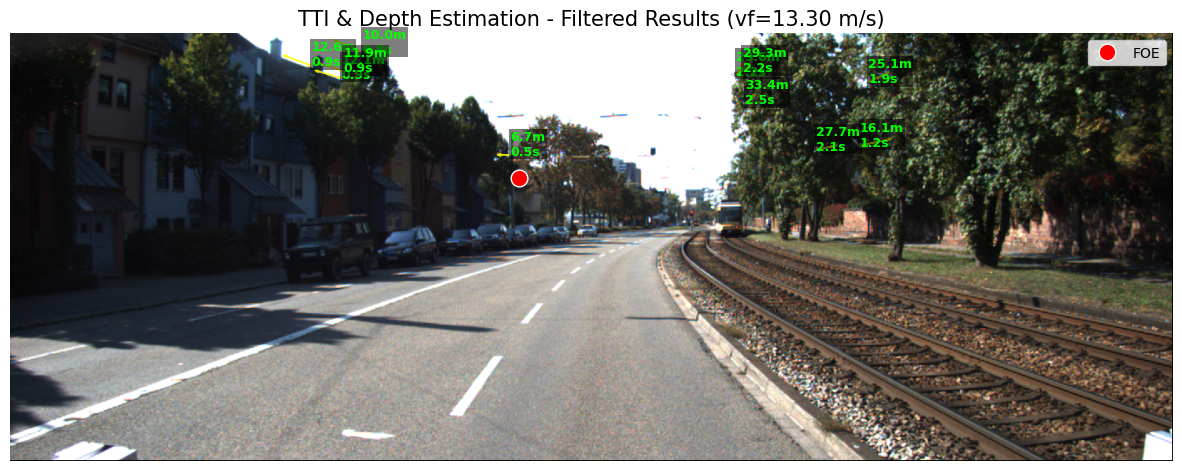

In [4]:
# 1. Recover the corresponding p1 points for the filtered set
# We use the same masks applied to obtain final_p0
p1_valid = p1[mask_flow][valid_z_mask]

# 2. Call the centralized visualization function
# We pass the image, points (t and t+1), depths, FOE, and velocity
plot_tti_and_depth(
    img=img_t,
    p0=final_p0,
    p1=p1_valid,
    depths=final_depths,
    foe=foe,
    vf=vf,
    title="TTI & Depth Estimation - Filtered Results"
)

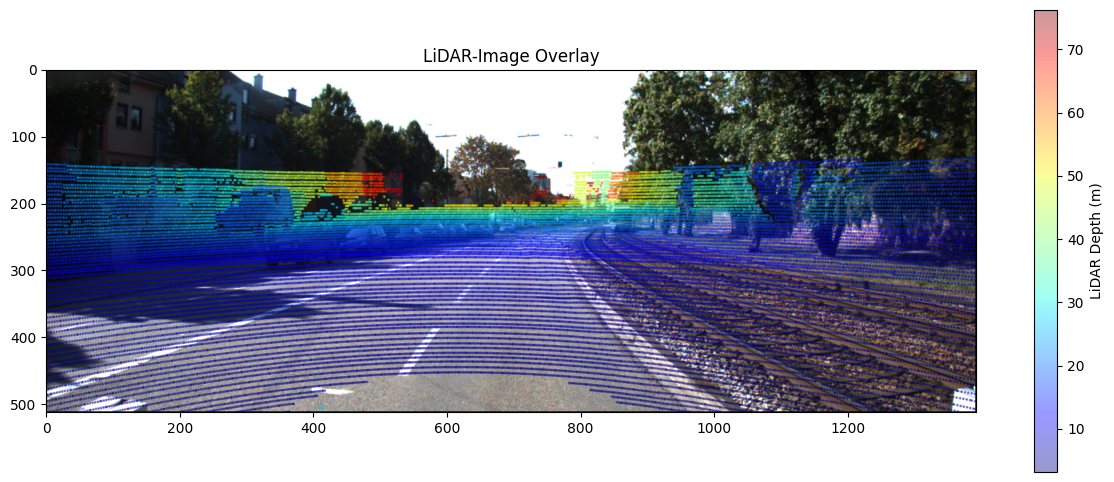

--- VALIDATION STATISTICS ---
LiDAR-matched points: 2
Mean Relative Error (MRE): 26.80%


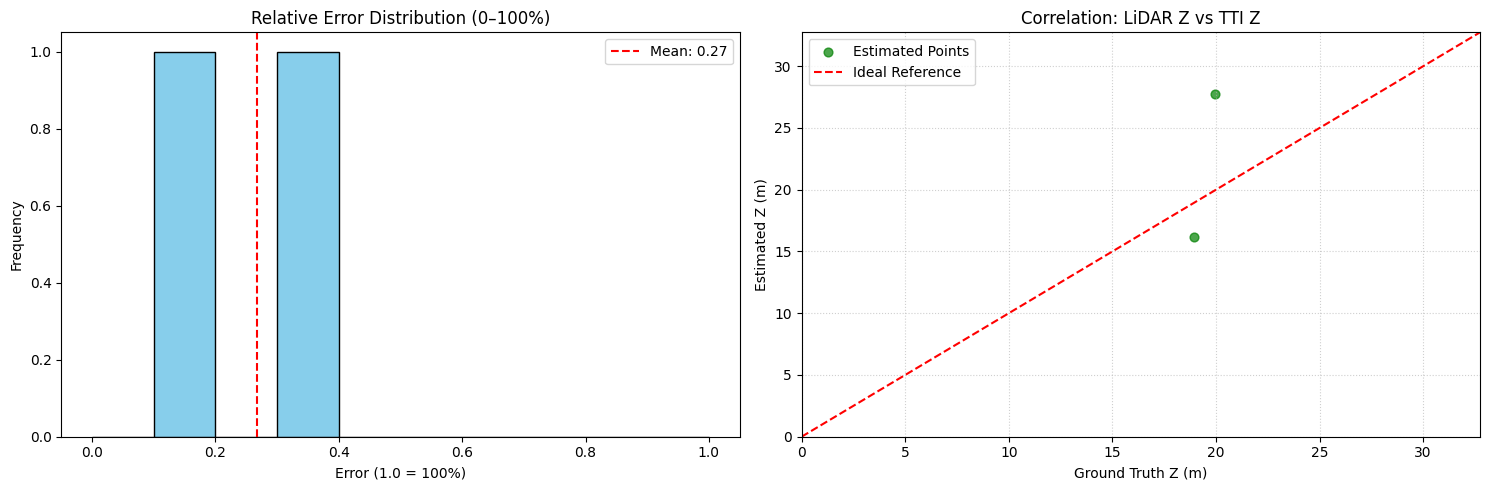

In [5]:
# Load and project LiDAR points
velo_file = os.path.join(BASE_PATH, f"velodyne_points/data/{idx_t:010d}.txt")
pts_3d = load_velodyne_points(velo_file)

# Proximity filter (car hood removal)
pts_3d = pts_3d[pts_3d[:, 0] > 2]

pts_2d, gt_depths = project_velo_to_image(
    pts_3d,
    P_rect,
    Tr_velo_to_cam
)

# Visual alignment check
plot_lidar_overlay(img_t, pts_2d, gt_depths)

# Spatial matching (cKDTree) for comparison
tree = cKDTree(pts_2d)
errors = []
z_comparison = []

for i, pt_est in enumerate(final_p0):
    # Find the closest LiDAR point within a 30-pixel radius
    dist_px, idx_lidar = tree.query(pt_est, distance_upper_bound=30)

    if dist_px < 30:
        z_gt = gt_depths[idx_lidar]
        z_est = final_depths[i]

        errors.append(abs(z_est - z_gt) / z_gt)
        z_comparison.append((z_gt, z_est))

# Final statistics and plots
if errors:
    print(f"--- VALIDATION STATISTICS ---")
    print(f"LiDAR-matched points: {len(errors)}")
    print(f"Mean Relative Error (MRE): {np.mean(errors)*100:.2f}%")

    plot_validation_stats(errors, z_comparison)
else:
    print("Error: No matches found with LiDAR.")